# HGEFS

In December 2025, NOAA announced the release of three AI global forecasting systems.

[NOAA deploys new generation of AI-driven global weather models](https://www.noaa.gov/news-release/noaa-deploys-new-generation-of-ai-driven-global-weather-models)

All three models are available for download in Herbie:

- `model="aigfs"`

- `model="aigefs"`

- `model="hgefs"`

This notebook demonstrates how to download and use HGEFS data using Herbie.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from herbie import Herbie, paint
from herbie.toolbox import EasyMap, ccrs, pc

There are two available products: 

- `product="sfc"`
- `product="pres"`

You must specify the member

- `member="spr"`
- `member="avg"`

In [2]:
H = Herbie("2026-02-01", model="hgefs", product="sfc", member="avg")
H

✅ Found ┊ model=hgefs ┊ product=sfc ┊ 2026-Feb-01 00:00 UTC F00 ┊ GRIB2 @ nomads ┊ IDX @ local


▌▌Herbie HGEFS model sfc product initialized 2026-Feb-01 00:00 UTC F00 ┊ source=nomads

In [3]:
# Show all available sources
H.SOURCES

{'nomads': 'https://nomads.ncep.noaa.gov/pub/data/nccf/com/hgefs/prod/hgefs.20260201/00/ensstat/products/atmos/grib2/hgefs.t00z.sfc.avg.f000.grib2'}

In [4]:
H.inventory()

,grib_message,start_byte,end_byte,range,reference_time,valid_time,variable,level,forecast_time,?,search_this
0,1,0,860132.0,0-860132,2026-02-01,2026-02-01,UGRD,10 m above ground,anl,ens mean,:UGRD:10 m above ground:anl:ens mean:
1,2,860133,1680810.0,860133-1680810,2026-02-01,2026-02-01,VGRD,10 m above ground,anl,ens mean,:VGRD:10 m above ground:anl:ens mean:
2,3,1680811,2131433.0,1680811-2131433,2026-02-01,2026-02-01,TMP,2 m above ground,anl,ens mean,:TMP:2 m above ground:anl:ens mean:
3,4,2131434,NaN,2131434-,2026-02-01,2026-02-01,PRMSL,mean sea level,anl,ens mean,:PRMSL:mean sea level:anl:ens mean:


In [5]:
ds = H.xarray("GRD:10 m")
ds

/home/blaylock/GITHUB/Herbie/.venv/lib/python3.13/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)


<xarray.Dataset> Size: 8MB
Dimensions:              (latitude: 721, longitude: 1440)
Coordinates:
  * latitude             (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude            (longitude) float64 12kB 0.0 0.25 0.5 ... 359.5 359.8
    time                 datetime64[ns] 8B 2026-02-01
    step                 timedelta64[ns] 8B 00:00:00
    heightAboveGround    float64 8B 10.0
    valid_time           datetime64[ns] 8B 2026-02-01
    gribfile_projection  object 8B None
Data variables:
    u10                  (latitude, longitude) float32 4MB -6.69 -6.7 ... -5.87
    v10                  (latitude, longitude) float32 4MB -0.96 -0.93 ... 1.48
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          2
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    model:                   hgefs
    product:                 sfc
    description:             Hybrid Global Ensemble Forecast System (HGEFS)
    remote_grib:             https://nomads.ncep.noaa.gov/pub/data/nccf/com/h...
    local_grib:              /home/blaylock/data/hgefs/20260201/subset_afeff9...
    search:                  GRD:10 m

Text(0.0, 1.0, 'HGEFS Ensemble Mean')

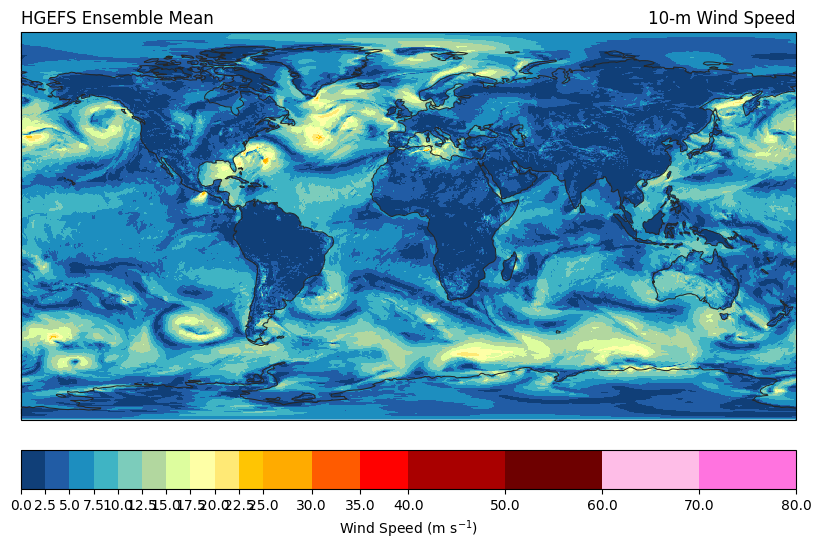

In [6]:
ax = EasyMap(crs=ds.herbie.crs, figsize=[10, 8]).ax
p = ax.pcolormesh(
    ds.longitude,
    ds.latitude,
    np.sqrt(ds.u10**2 + ds.v10**2),
    transform=pc,
    **paint.NWSWindSpeed.kwargs2,
)
plt.colorbar(
    p,
    ax=ax,
    orientation="horizontal",
    pad=0.05,
    **paint.NWSWindSpeed.cbar_kwargs2,
)

ax.set_title("10-m Wind Speed", loc="right")
ax.set_title(f"{ds.model.upper()} Ensemble Mean", loc="left")